# Classification - Credit Score

## By: Ayush Trivedi

### Importing Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

### Loading the Data

In [2]:
df = pd.read_csv(r"C:\Users\ayush\Downloads\Credit_Score\credit_score.csv")
df=df.drop(columns=["ID","Customer_ID","Name","SSN","Type_of_Loan","Credit_History_Age"])
df.head()

C:\Users\ayush\AppData\Local\Temp/ipykernel_21988/750407877.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\ayush\Downloads\Credit_Score\credit_score.csv")


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,...,4.0,_,809.98,26.822620,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,February,23,Scientist,19114.12,NaN,3,4,3,4,-1,...,4.0,Good,809.98,31.944960,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,March,-500,Scientist,19114.12,NaN,3,4,3,4,3,...,4.0,Good,809.98,28.609352,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,April,23,Scientist,19114.12,NaN,3,4,3,4,5,...,4.0,Good,809.98,31.377862,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,...,4.0,Good,809.98,24.797347,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  object 
 1   Age                       100000 non-null  object 
 2   Occupation                100000 non-null  object 
 3   Annual_Income             100000 non-null  object 
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  object 
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   object 
 11  Changed_Credit_Limit      100000 non-null  object 
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                100000 non-null  ob

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


### Missing Values

In [4]:
df.isnull().sum()

Month                           0
Age                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

### Data Cleaning

In [9]:
df["Age"] = df["Age"].astype(str).str.replace("_", "")
df["Age"] = df["Age"].astype(int)
df["Annual_Income"] = df["Annual_Income"].astype(str).str.replace("_", "")
df["Annual_Income"] = df["Annual_Income"].astype(float)
df["Num_of_Loan"] = df["Num_of_Loan"].astype(str).str.replace("_", "")
df["Num_of_Loan"] = df["Num_of_Loan"].astype(int)
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].astype(str).str.replace("_", "")
df["Num_of_Delayed_Payment"] = df["Num_of_Delayed_Payment"].astype(float)
df["Monthly_Balance"] = df["Monthly_Balance"].astype(str).str.replace("_", "")
df["Monthly_Balance"] = df["Monthly_Balance"].astype(float)
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].astype(str).str.replace("_", "")
df["Amount_invested_monthly"] = df["Amount_invested_monthly"].astype(float)
df["Outstanding_Debt"] = df["Outstanding_Debt"].astype(str).str.replace("_", "")
df["Outstanding_Debt"] = df["Outstanding_Debt"].astype(float)
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].astype(str).replace("_", np.nan)
df["Changed_Credit_Limit"] = df["Changed_Credit_Limit"].astype(float)
df["Occupation"] = df["Occupation"].replace("_______", np.nan)
df["Credit_Score"] = df["Credit_Score"].replace({"Poor": 0, "Standard": 1, "Good": 2})
df["Credit_Mix"] = df["Credit_Mix"].replace({"Standard": 1, "Good": 2, "Bad": 0})
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)
df["Payment_Behaviour"] = df["Payment_Behaviour"].replace("!@9#%8", np.nan)
df["Payment_of_Min_Amount"] = df["Payment_of_Min_Amount"].replace({"NM": "No", "Yes": 1, "No": 0})

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  object 
 1   Age                       100000 non-null  int32  
 2   Occupation                92938 non-null   object 
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     84998 non-null   float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int32  
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    92998 non-null   float64
 11  Changed_Credit_Limit      97909 non-null   float64
 12  Num_Credit_Inquiries      98035 non-null   float64
 13  Credit_Mix                79805 non-null   fl

In [11]:
df.isnull().sum()
df=df.fillna(method="ffill")
df=df.fillna(method="bfill")
df.isnull().sum()

Month                       0
Age                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

C:\Users\ayush\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


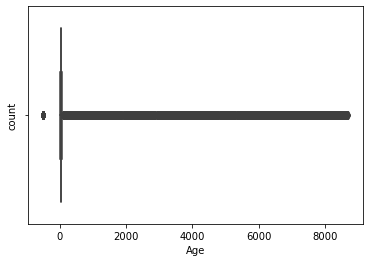

In [12]:
sns.boxplot(df["Age"])
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

C:\Users\ayush\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


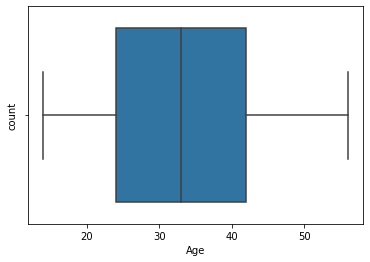

In [14]:
col_names=["Age"]
Q1=df.Age.quantile(0.25)
Q3=df.Age.quantile(0.75)
IQR=Q3-Q1
data=df[(df.Age>=Q1-1.5*IQR)&(df.Age<=Q3+1.5*IQR)]
sns.boxplot(data["Age"])
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

In [16]:
le= LabelEncoder()
df["Month"]=le.fit_transform(df["Month"])
df["Occupation"]=le.fit_transform(df["Occupation"])
df["Payment_Behaviour"]=le.fit_transform(df["Payment_Behaviour"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int32  
 1   Age                       100000 non-null  int32  
 2   Occupation                100000 non-null  int32  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int32  
 9   Delay_from_due_date       100000 non-null  int64  
 10  Num_of_Delayed_Payment    100000 non-null  float64
 11  Changed_Credit_Limit      100000 non-null  float64
 12  Num_Credit_Inquiries      100000 non-null  float64
 13  Credit_Mix                100000 non-null  fl

### Feature Selection

In [20]:
col_list=[]
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'Credit_Score')):
        col_list.append(col)
X=df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                     feature       VIF
0                      Month  0.300012
1                        Age  0.974661
2                 Occupation  0.277722
3              Annual_Income  0.985001
4      Monthly_Inhand_Salary  0.365970
5          Num_Bank_Accounts  0.979247
6            Num_Credit_Card  0.970567
7              Interest_Rate  0.976430
8                Num_of_Loan  0.997697
9        Delay_from_due_date  0.332213
10    Num_of_Delayed_Payment  0.981707
11      Changed_Credit_Limit  0.299307
12      Num_Credit_Inquiries  0.979793
13                Credit_Mix  0.321474
14          Outstanding_Debt  0.396141
15  Credit_Utilization_Ratio  0.024506
16       Total_EMI_per_month  0.972258
17   Amount_invested_monthly  0.911321
18         Payment_Behaviour  0.310525
19           Monthly_Balance  1.000195


### Logistic Regression

In [29]:
categorical_cols = df.select_dtypes(include=['object']).columns
binary_cols = ["Payment_of_Min_Amount"]
for col in binary_cols:
    df[col] = df[col].replace({"Yes": 1, "No": 0})
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col not in binary_cols], drop_first=True)
y = df["Credit_Score"]
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print("Accuracy Score:", accuracy_score(y_test, y_pred))
result_df = pd.DataFrame({"actual_value": y_test, "predicted_value": y_pred})
print(result_df)

Accuracy Score: 0.61845
       actual_value  predicted_value
75721             2                2
80184             0                0
19864             2                2
76699             0                0
92991             2                2
...             ...              ...
32595             1                1
29313             1                1
37862             0                1
53421             1                1
42410             1                1

[20000 rows x 2 columns]


### Decision Tree

In [31]:
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print("Accuracy_Score:",accuracy_score(y_test,y_pred))
pd.DataFrame({"actual_value":y_test,'predicted_value':y_pred})

Accuracy_Score: 0.69455


,actual_value,predicted_value
75721,2,2
80184,0,0
19864,2,2
76699,0,0
92991,2,2
...,...,...
32595,1,1
29313,1,1
37862,0,0
53421,1,1


### HyperParameter Tuning on Decision Tree

In [36]:
parameters={'max_features':['log2','sqrt','auto'],
           'criterion':['entropy','gini'],
           'max_depth':[2,3,5,10,50],
           'min_samples_split':[2,3,50,100],
           'min_samples_leaf':[1,5,8,10]}
grid_obj=GridSearchCV(dt,parameters)
grid_obj=grid_obj.fit(x_train,y_train)
dt=grid_obj.best_estimator_
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
acc_dt=round(accuracy_score(y_test,y_pred)*100,2)
print('Accuracy of Decision tree Model:',acc_dt)

C:\Users\ayush\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
800 fits failed out of a total of 2400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
800 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ayush\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\ayush\anaconda3\lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\Users\ayush\anaconda3\lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\ayush\anaconda3\lib\site-packa

Accuracy of Decision tree Model: 70.66


### Random Forest

In [38]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)
y_pred=rfc.predict(x_test)
print("Accuracy_score:",accuracy_score(y_test,y_pred))
pd.DataFrame({"Actual_Value":y_test,"Predicted_Value":y_pred})

Accuracy_score: 0.7968


,Actual_Value,Predicted_Value
75721,2,2
80184,0,0
19864,2,2
76699,0,0
92991,2,2
...,...,...
32595,1,1
29313,1,1
37862,0,1
53421,1,1
